In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

In [3]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

print("Dataset Loaded Successfully!\n")
print(df.head())

Dataset Loaded Successfully!

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [4]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape of Dataset:
(20640, 9)

Column Names:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


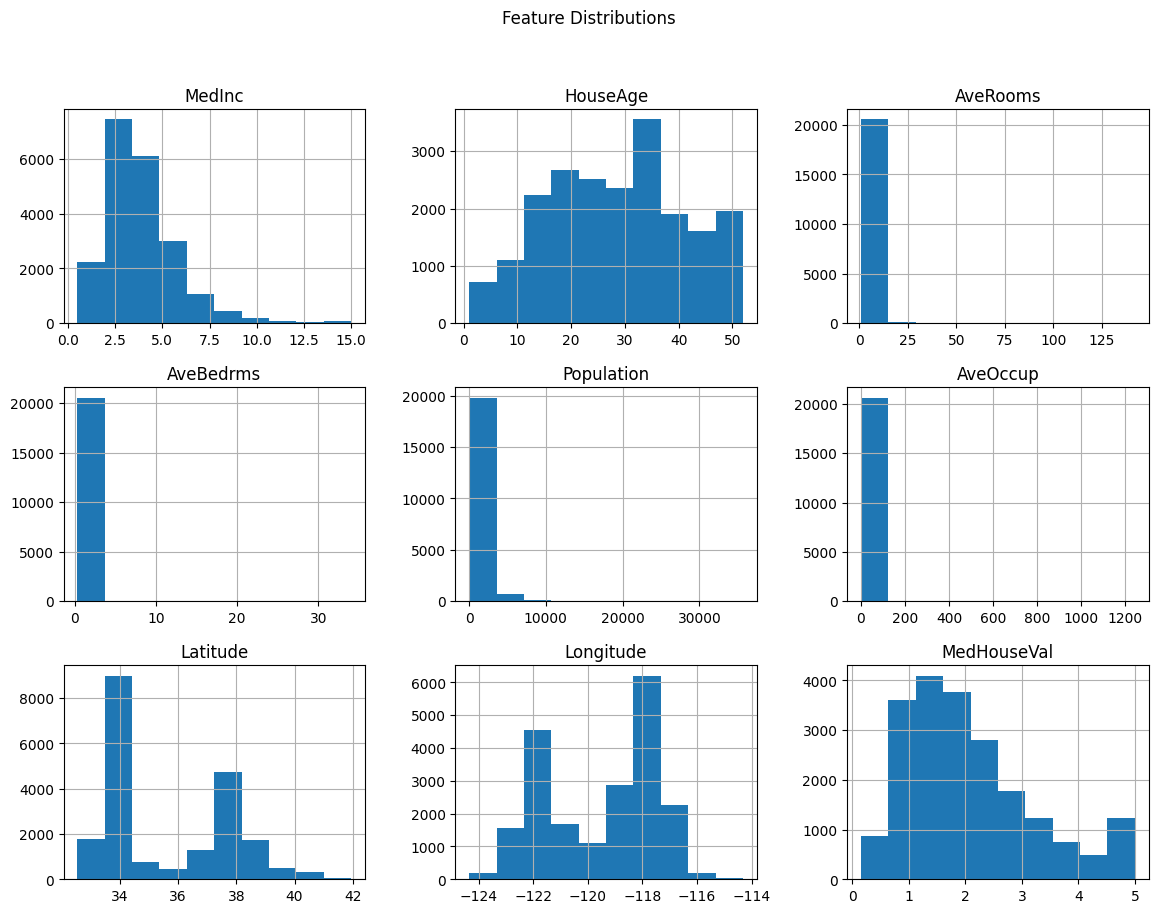

In [6]:
df.hist(figsize=(14,10))
plt.suptitle("Feature Distributions")
plt.show()

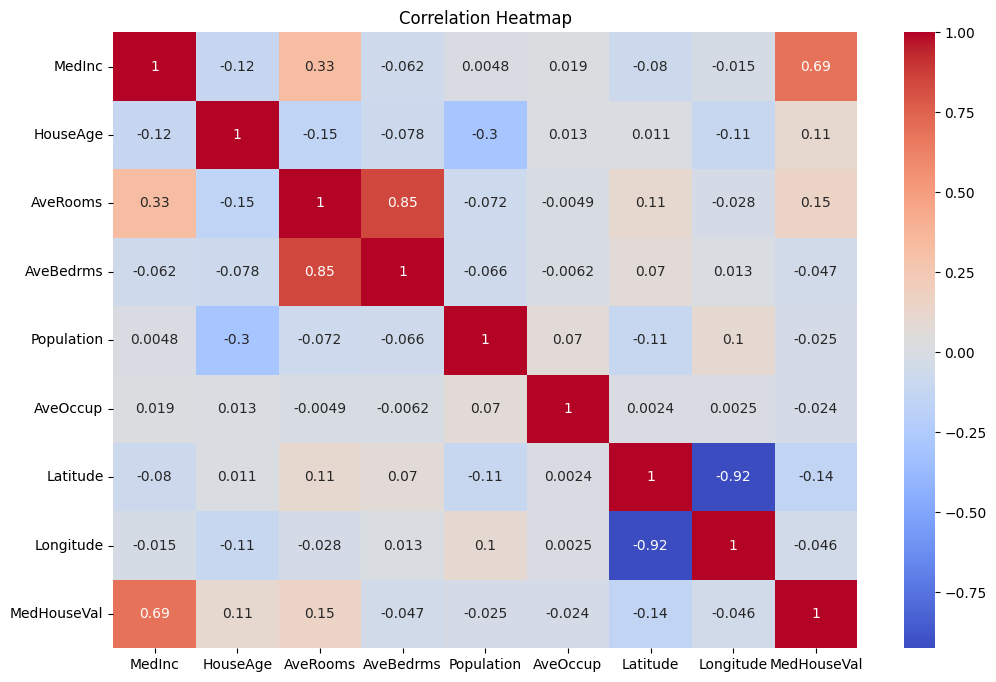

In [7]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

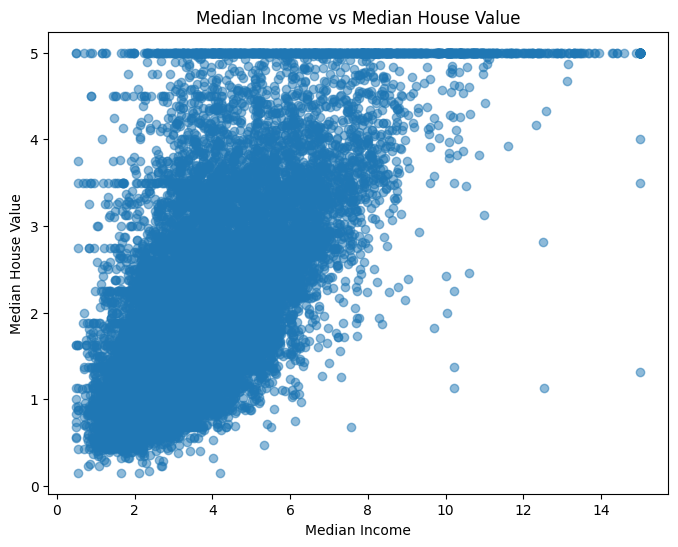

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.5)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")

plt.show()

In [9]:
X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]

print(X.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (16512, 8)
Testing Shape: (4128, 8)


In [11]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [12]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)


      Feature  Coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708


In [13]:
y_pred = model.predict(X_test)

print("First 10 Predictions")

print(y_pred[:10])

First 10 Predictions
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [14]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("------------------------")
print("Mean Absolute Error :", mae)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Model Evaluation
------------------------
Mean Absolute Error : 0.5332001304956555
Root Mean Squared Error : 0.7455813830127763
R2 Score : 0.575787706032451


In [16]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(20))

     Actual  Predicted
0   0.47700   0.719123
1   0.45800   1.764017
2   5.00001   2.709659
3   2.18600   2.838926
4   2.78000   2.604657
5   1.58700   2.011754
6   1.98200   2.645500
7   1.57500   2.168755
8   3.40000   2.740746
9   4.46600   3.915615
10  1.23200   0.938962
11  2.53900   1.901222
12  2.15100   1.758712
13  2.20500   2.250160
14  2.19800   2.540870
15  1.36200   1.917405
16  1.78400   2.386483
17  1.87500   2.010930
18  1.39800   2.227409
19  1.37500   1.118532


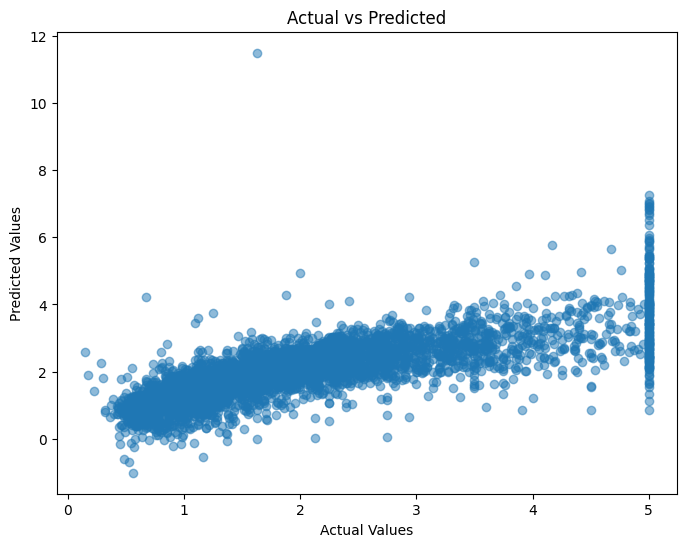

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

plt.show()

In [18]:
joblib.dump(model, "linear_regression_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [19]:
loaded_model = joblib.load("linear_regression_model.pkl")

print("Saved Model Loaded Successfully!")


Saved Model Loaded Successfully!


In [20]:
sample = X.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Predicted House Value:")
print(prediction)

Predicted House Value:
[4.15194269]
